## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
games_df = pd.read_csv("vgsales.csv")

## Initial EDA

In [3]:
games_df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
games_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 3.0 MB


In [5]:
games_df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


### Meaning of `describe`

Although null values will be handled later, this statistical summary is useful for understanding the structure of the dataset before cleaning.

Note that:

- There is a large difference between the mean and median in `Global_Sales`, which indicates a highly skewed distribution.
- There is evidence of outliers, which is expected in a market where a small number of games achieve very high success while many others have much lower sales.
- Fewer than 25% of the games were released after 2010, with 2007 as the median release year.

In [6]:
print("Before drop duplicates")
print(games_df.shape)                                             # Check size before drop

# Drop Duplicates
games_df = games_df.drop_duplicates()                             # Drop Duplicated

print("after drop duplicates")
print(games_df.shape)                                             # Check size after drop

Before drop duplicates
(16719, 16)
after drop duplicates
(16719, 16)


## Null Values

In [7]:
# Check null values
games_df.isnull().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

In [8]:
# Check % average of null values in all features with null values.
print("\n--- Features with small % of null values (less than 2%) ---")
print(f"Name: {games_df['Name'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Year of Release: {games_df['Year_of_Release'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Genre: {games_df['Genre'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Publisher: {games_df['Publisher'].isnull().sum()/games_df.shape[0]:.2%}")

print("\n--- Features with relevant % of null values ---")
print(f"Critical Score: {games_df['Critic_Score'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Critical Count: {games_df['Critic_Count'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"User Score: {games_df['User_Score'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"User Count: {games_df['User_Count'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Developer: {games_df['Developer'].isnull().sum()/games_df.shape[0]:.2%}")
print(f"Rating: {games_df['Rating'].isnull().sum()/games_df.shape[0]:.2%}")


--- Features with small % of null values (less than 2%) ---
Name: 0.01%
Year of Release: 1.61%
Genre: 0.01%
Publisher: 0.32%

--- Features with relevant % of null values ---
Critical Score: 51.33%
Critical Count: 51.33%
User Score: 40.10%
User Count: 54.60%
Developer: 39.61%
Rating: 40.49%


### Handling Null Values

The dataset contains missing values in several variables, but in different proportions, therefore requiring distinct handling strategies.

- Columns with less than 2% missing values were handled by removing the affected rows.

- Variables with a high proportion of missing values were excluded from the dataset, as imputation would require strong assumptions and could introduce bias.
  
- Assessment-related variables also show uneven distribution across release years, making it risky to impute values without compromising data quality.

#### Drop Null Values < 2%

| Feature          | Null Values (%) |
|------------------|-----------------|
| Name             | 0.01%           |
| Year of Release  | 1.61%           |
| Genre            | 0.01%           |
| Publisher        | 0.32%           |

In [9]:
# Drop rows with null values
games_df = games_df.dropna(subset = ['Name','Year_of_Release','Genre','Publisher'])

#### Features with Relevant % of Null Values

| Feature        | Null Values (%) |
|----------------|-----------------|
| Critic Score   | 51.33%          |
| Critic Count   | 51.33%          |
| User Score     | 40.10%          |
| User Count     | 54.60%          |
| Rating         | 40.49%          |

These columns were removed because the proportion of missing values is too high for reliable analysis without substantial imputation. Since the dataset covers release years from 1980 to 2020, review-related variables are also uneven across time, which could introduce additional bias and reduce comparability.

In [10]:
# Drop columns with too much null values
games_df = games_df.drop(columns = ['Critic_Score','Critic_Count','User_Score','User_Count','Rating'])

In [11]:
# Check null values
games_df.isnull().sum()

Name                  0
Platform              0
Year_of_Release       0
Genre                 0
Publisher             0
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Developer          6512
dtype: int64

In [12]:
print(f"Percentage of null values in the feature developer:{games_df['Developer'].isnull().sum()/ len(games_df) * 100:.2f}%")

Percentage of null values in the feature developer:39.67%


#### Developer

| Feature        | Null Values (%) |
|----------------|-----------------|
| Developer      | 39.67%          |


Considering the null values of the 'Developer' feature and always maintaining the objective of using the maximum available data, without introducing bias and noise into the analysis, these values can be replaced with 'Unknown'.

In [13]:
# Replace null values for Unknown
games_df['Developer'] = games_df['Developer'].fillna('Unknown')

In [14]:
# Check null values
games_df.isnull().sum()

Name               0
Platform           0
Year_of_Release    0
Genre              0
Publisher          0
NA_Sales           0
EU_Sales           0
JP_Sales           0
Other_Sales        0
Global_Sales       0
Developer          0
dtype: int64

In [15]:
games_df.info()

<class 'pandas.DataFrame'>
Index: 16416 entries, 0 to 16718
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16416 non-null  str    
 1   Platform         16416 non-null  str    
 2   Year_of_Release  16416 non-null  float64
 3   Genre            16416 non-null  str    
 4   Publisher        16416 non-null  str    
 5   NA_Sales         16416 non-null  float64
 6   EU_Sales         16416 non-null  float64
 7   JP_Sales         16416 non-null  float64
 8   Other_Sales      16416 non-null  float64
 9   Global_Sales     16416 non-null  float64
 10  Developer        16416 non-null  str    
dtypes: float64(6), str(5)
memory usage: 2.4 MB


In [16]:
# Convert Year_of_Release to int after removing null values
games_df['Year_of_Release'] = games_df['Year_of_Release'].astype(int)

In [17]:
# Check if it worked
games_df.info()

<class 'pandas.DataFrame'>
Index: 16416 entries, 0 to 16718
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16416 non-null  str    
 1   Platform         16416 non-null  str    
 2   Year_of_Release  16416 non-null  int64  
 3   Genre            16416 non-null  str    
 4   Publisher        16416 non-null  str    
 5   NA_Sales         16416 non-null  float64
 6   EU_Sales         16416 non-null  float64
 7   JP_Sales         16416 non-null  float64
 8   Other_Sales      16416 non-null  float64
 9   Global_Sales     16416 non-null  float64
 10  Developer        16416 non-null  str    
dtypes: float64(5), int64(1), str(5)
memory usage: 2.4 MB


## EDA
The EDA was included as a necessary preparatory step to understand the dataset structure, identify missing values, and support the visualization choices used in the final answers.

### Genres

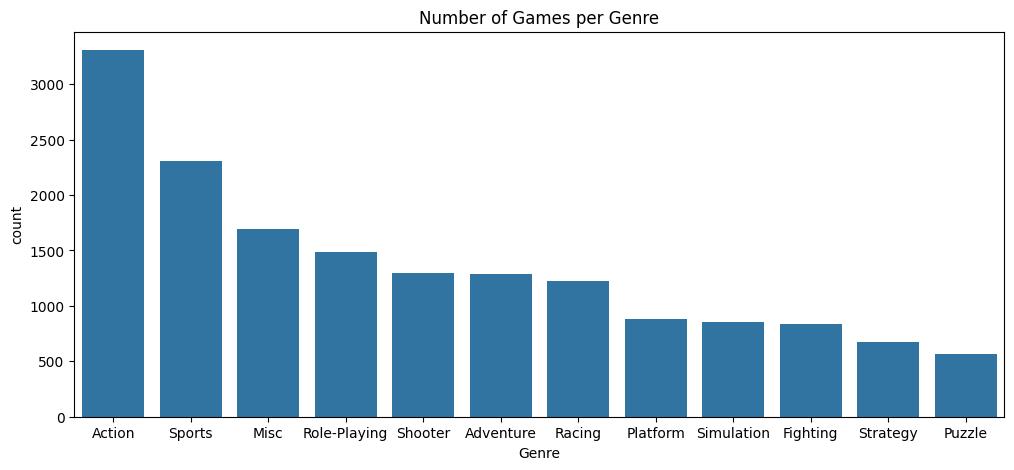

In [18]:
# Graph to identify the quantity of titles by genre.
plt.figure(figsize=(12, 5))                                                       
sns.countplot(data=games_df, x='Genre', stat='count',                             
              order=games_df['Genre'].value_counts().index)                       
plt.title('Number of Games per Genre')                                            
plt.show()

In [19]:
# View the first 25 action games
games_df[games_df['Genre'] == 'Action'].head(25)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Developer
16,Grand Theft Auto V,PS3,2013,Action,Take-Two Interactive,7.02,9.09,0.98,3.96,21.04,Rockstar North
17,Grand Theft Auto: San Andreas,PS2,2004,Action,Take-Two Interactive,9.43,0.40,0.41,10.57,20.81,Rockstar North
23,Grand Theft Auto V,X360,2013,Action,Take-Two Interactive,9.66,5.14,0.06,1.41,16.27,Rockstar North
24,Grand Theft Auto: Vice City,PS2,2002,Action,Take-Two Interactive,8.41,5.49,0.47,1.78,16.15,Rockstar North
38,Grand Theft Auto III,PS2,2001,Action,Take-Two Interactive,6.99,4.51,0.30,1.30,13.10,DMA Design
42,Grand Theft Auto V,PS4,2014,Action,Take-Two Interactive,3.96,6.31,0.38,1.97,12.61,Rockstar North
46,Pokemon HeartGold/Pokemon SoulSilver,DS,2009,Action,Nintendo,4.34,2.71,3.96,0.76,11.77,Unknown
51,Grand Theft Auto IV,X360,2008,Action,Take-Two Interactive,6.76,3.07,0.14,1.03,11.01,Rockstar North
57,Grand Theft Auto IV,PS3,2008,Action,Take-Two Interactive,4.76,3.69,0.44,1.61,10.50,Rockstar North
81,FIFA Soccer 13,PS3,2012,Action,Electronic Arts,1.06,5.01,0.13,1.97,8.16,Electronic Arts


#### Action Genre

Action games represent the most common genre. However, a question arises, as the action genre is very broad, as evidenced by the example below:

- FIFA Soccer 13 is listed as action
- Grand Theft Auto (GTA) is also.

However, from a gamer's perspective, GTA could be considered a shooter, and FIFA a sports game. Therefore, despite the classification given by developers/distributors, these premises should be considered to extract good insights from this information.

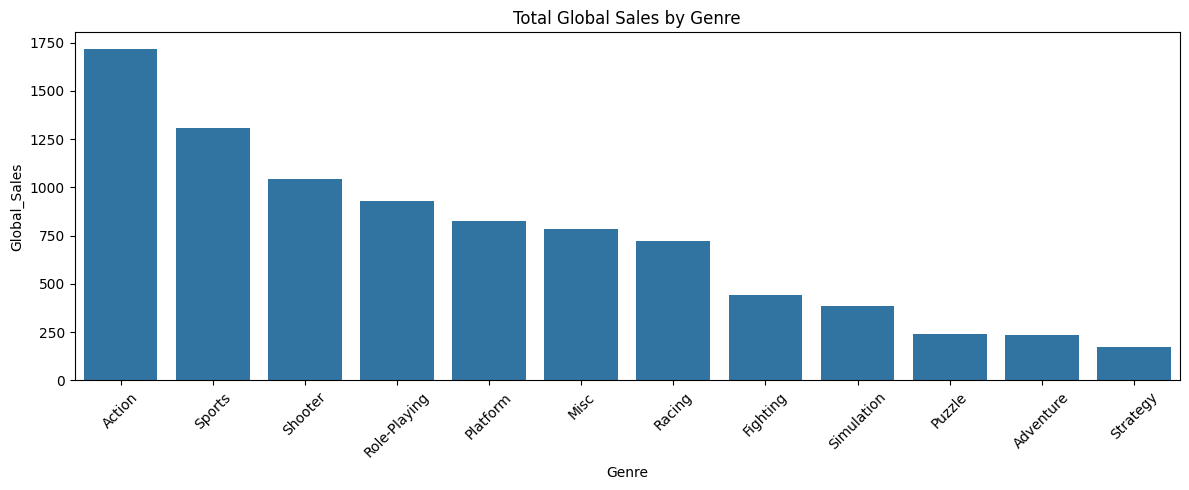

In [20]:
plt.figure(figsize=(12, 5))                                                                 
sns.barplot(data=games_df, x='Genre', y='Global_Sales',                                      
            estimator='sum', errorbar=None,                                                  
            order=games_df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).index)
plt.xticks(rotation=45)                                                                     
plt.title('Total Global Sales by Genre')                                                     
plt.tight_layout()                                                                          
plt.show()

#### Count per Genre x Global Sales 

- This chart compares total global sales across genres and helps identify which categories generated the highest overall sales in the dataset.

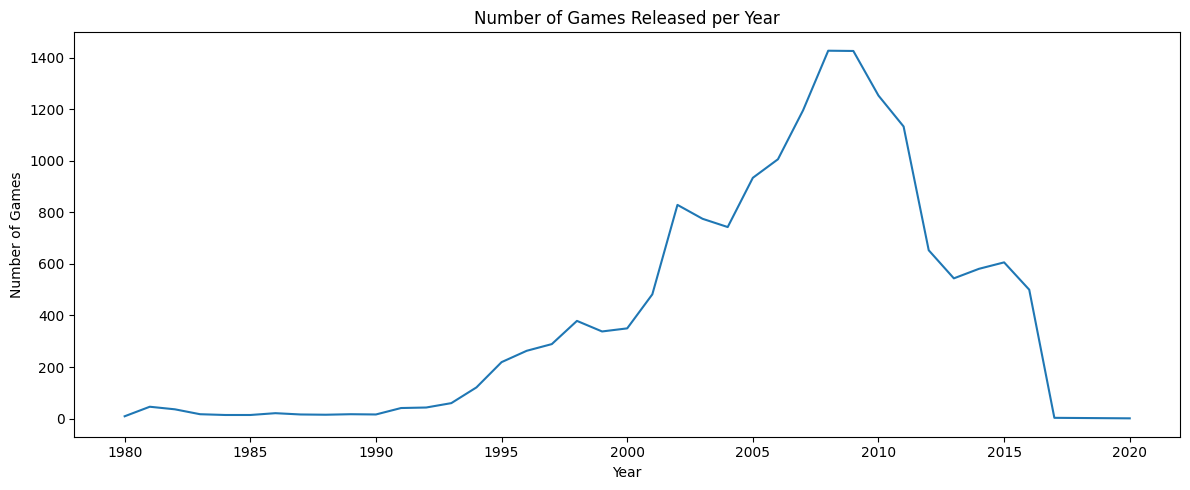

In [21]:
plt.figure(figsize=(12, 5))                                                       
games_df['Year_of_Release'].value_counts().sort_index().plot(kind='line')           
plt.title('Number of Games Released per Year')                                      
plt.xlabel('Year')                                                                 
plt.ylabel('Number of Games')                                                      
plt.tight_layout()                                                                 
plt.show()                                                                       

> This chart shows how game releases changed over time and provides context for the rest of the analysis.

#### Release per Year x Action Genre

Before checking the total releases of the Action genre per year, it is important to understand the overall release pattern per year, and not just for a specific genre.

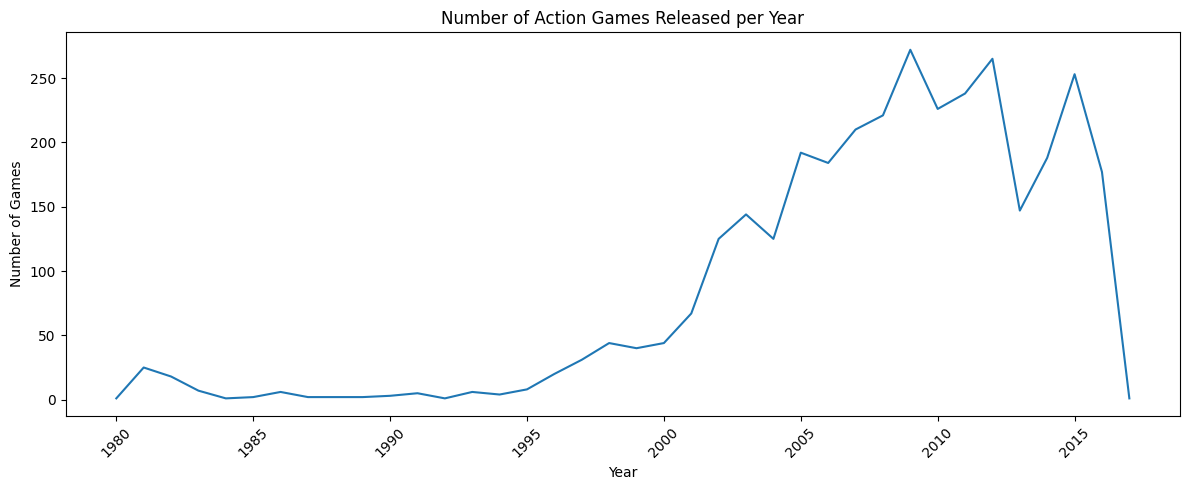

In [22]:
plt.figure(figsize=(12, 5))                                                                                       
games_df[games_df['Genre'] == 'Action']['Year_of_Release'].value_counts().sort_index().plot(kind='line')          
plt.title('Number of Action Games Released per Year')                                                             
plt.xlabel('Year')                                                                                                
plt.ylabel('Number of Games')                                                                                     
plt.locator_params(integer=True)                                                                                  
plt.xticks(rotation=45)                                                                                           
plt.tight_layout()                                                                                                
plt.show()

#### Genre Conclusion
- This chart compares Action releases with the overall yearly trend and helps show whether the genre follows the same pattern as the dataset as a whole.

### Developers

In [23]:
# View the unique developer name
games_df['Developer'].unique()

<ArrowStringArray>
[                                 'Nintendo',
                                   'Unknown',
                       'Good Science Studio',
                            'Rockstar North',
                         'Polyphony Digital',
         'Infinity Ward, Sledgehammer Games',
                                  'Treyarch',
                             'Infinity Ward',
                                'DMA Design',
                                 'Game Arts',
 ...
                               'React Games',
       'Bigben Interactive, Red Wagon Games',
                                   'Papyrus',
                             'Inferno Games',
                       'Katauri Interactive',
 'High Moon Studios, Mercenary Technologies',
                'Infinite Dreams, Paragon 5',
                          'Big Red Software',
                              'Atomic Games',
                        'Interchannel-Holon']
Length: 1681, dtype: str

In [24]:
# As we can see, there are too many developers, so we need to count it and order
games_df['Developer'].value_counts().head(25)

Developer
Unknown                         6512
Ubisoft                          201
EA Sports                        169
EA Canada                        164
Konami                           158
Capcom                           137
EA Tiburon                       104
Electronic Arts                  101
Ubisoft Montreal                 100
Visual Concepts                   98
Omega Force                       80
Activision                        75
Vicarious Visions                 74
TT Games                          73
Nintendo                          72
THQ                               71
Traveller's Tales                 65
Namco                             64
Codemasters                       61
Yuke's                            59
Midway                            58
Artificial Mind and Movement      56
High Voltage Software             54
Harmonix Music Systems            52
Maxis                             49
Name: count, dtype: int64

#### Group major developers to reduce name fragmentation in the dataset. This makes it easier to analyze the most common companies.

In [25]:
# Create a function to map the developers
# It's not possible to do this manually, as there are over 1200 companies, but the best-known ones will be on the list.

def map_developer(dev):                         
    dev = str(dev).lower()                                         # Convert to string and lowercase to avoid issues with case-insensitive comparison
    if 'ubisoft' in dev:                                           # Group all Ubisoft studios
        return 'Ubisoft'
    if 'electronic arts' in dev or dev == 'ea' or dev.startswith('ea ') or dev.endswith(' ea'):
        return 'Electronic Arts'                                   # Group EA and Electronic Arts variants
    if 'activision' in dev:                                        # Group all Activision studios
        return 'Activision'
    if 'konami' in dev:                                            # Group all Konami studios
        return 'Konami'
    if 'capcom' in dev:                                            # Group all Capcom studios
        return 'Capcom'
    if 'sega' in dev:                                              # Group all Sega studios
        return 'Sega'
    if 'nintendo' in dev:                                          # Group all Nintendo studios
        return 'Nintendo'
    if 'sony' in dev:                                              # Group all Sony studios
        return 'Sony'
    if 'namco' in dev:                                             # Group all Namco studios
        return 'Namco'
    if 'rockstar' in dev:                                          # Group all Rockstar studios
        return 'Rockstar'    
    return dev.title()                                             # Return the original developer name with title case

# Apply the mapping function to create a new grouped developer column
games_df['Developer_Group'] = games_df['Developer'].apply(map_developer)

In [26]:
# View the unique developer name after mapping
games_df['Developer_Group'].unique()

<ArrowStringArray>
[                                 'Nintendo',
                                   'Unknown',
                       'Good Science Studio',
                                  'Rockstar',
                         'Polyphony Digital',
         'Infinity Ward, Sledgehammer Games',
                                  'Treyarch',
                             'Infinity Ward',
                                'Dma Design',
                                 'Game Arts',
 ...
                               'React Games',
       'Bigben Interactive, Red Wagon Games',
                                   'Papyrus',
                             'Inferno Games',
                       'Katauri Interactive',
 'High Moon Studios, Mercenary Technologies',
                'Infinite Dreams, Paragon 5',
                          'Big Red Software',
                              'Atomic Games',
                        'Interchannel-Holon']
Length: 1562, dtype: str

> Using the map function, the number of unique developers was reduced from 1681 to 1441.

In [27]:
# Check the output
games_df['Developer_Group'].value_counts().head(10)

Developer_Group
Unknown            6512
Electronic Arts     716
Ubisoft             451
Konami              171
Capcom              146
Namco               133
Visual Concepts      98
Nintendo             88
Activision           84
Omega Force          80
Name: count, dtype: int64

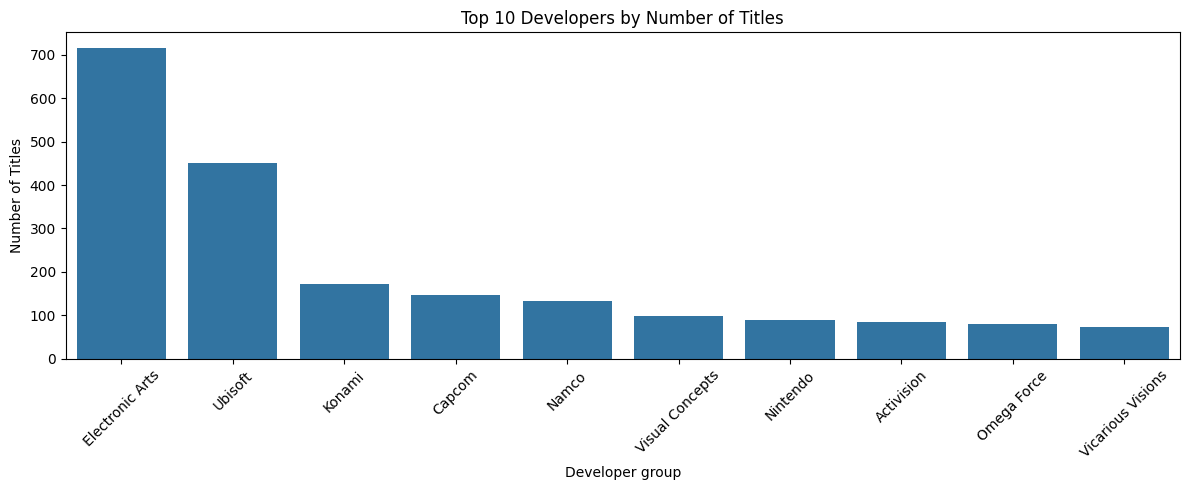

In [28]:
df_no_unknown = games_df[games_df['Developer_Group'] != 'Unknown']

plt.figure(figsize=(12, 5))
sns.barplot(
    x=df_no_unknown['Developer_Group'].value_counts().head(10).index,
    y=df_no_unknown['Developer_Group'].value_counts().head(10).values,
    errorbar=None
)
plt.title('Top 10 Developers by Number of Titles')
plt.xlabel('Developer group')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

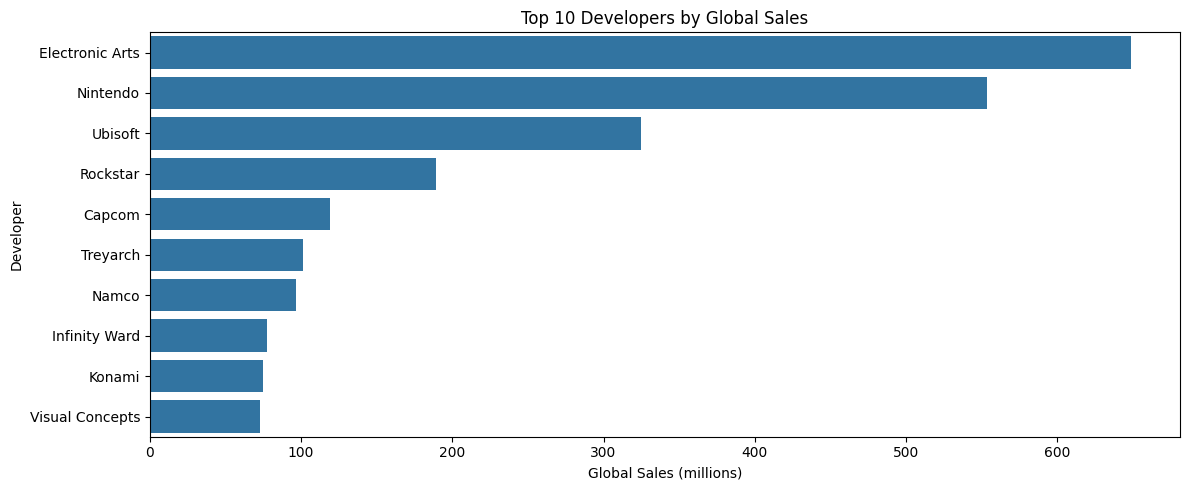

In [29]:
plt.figure(figsize=(12, 5))                                                                            
top10_dev_sales = games_df[games_df['Developer_Group'] != 'Unknown'
    ].groupby('Developer_Group')['Global_Sales'].sum().sort_values(ascending=False).head(10)           
sns.barplot(x=top10_dev_sales.values, y=top10_dev_sales.index, errorbar=None)
plt.title('Top 10 Developers by Global Sales')                                                         
plt.xlabel('Global Sales (millions)')                                                                 
plt.ylabel('Developer')                                                                                
plt.tight_layout()                                                                                     
plt.show()

#### In general, companies with more titles hold the same position in the global sales ranking. However, there are exceptions:
- Nintendo only loses to Electronic Arts in terms of Global Sales, but it is worth noting that EA has between 5 to 6 times more titles released.
- Rockstar, despite not having as many titles, reached an impressive 4th place in the sales ranking.
- These two exceptions can be explained by one or more major commercial successes.

In [30]:
# View the top 10 Nintendo games
games_df[games_df['Developer_Group'] == 'Nintendo'][['Name', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)

,Name,Global_Sales
0,Wii Sports,82.53
2,Mario Kart Wii,35.52
3,Wii Sports Resort,32.77
6,New Super Mario Bros.,29.80
7,Wii Play,28.92
8,New Super Mario Bros. Wii,28.32
11,Mario Kart DS,23.21
13,Wii Fit,22.70
15,Wii Fit Plus,21.79
19,Brain Age: Train Your Brain in Minutes a Day,20.15


In [31]:
# View the top 10 Rockstar games
games_df[games_df['Developer_Group'] == 'Rockstar'][['Name', 'Global_Sales']].sort_values('Global_Sales', ascending=False).head(10)

,Name,Global_Sales
16,Grand Theft Auto V,21.04
17,Grand Theft Auto: San Andreas,20.81
23,Grand Theft Auto V,16.27
24,Grand Theft Auto: Vice City,16.15
42,Grand Theft Auto V,12.61
51,Grand Theft Auto IV,11.01
57,Grand Theft Auto IV,10.50
91,Grand Theft Auto: Liberty City Stories,7.69
125,Red Dead Redemption,6.49
135,Red Dead Redemption,6.32


#### Developers Conclusion

- The top 10 global sales show that companies like Nintendo and Rockstar can perform very well even with fewer titles. This means that having more games does not necessarily lead to higher commercial success.

### Global Sales x Region Sales

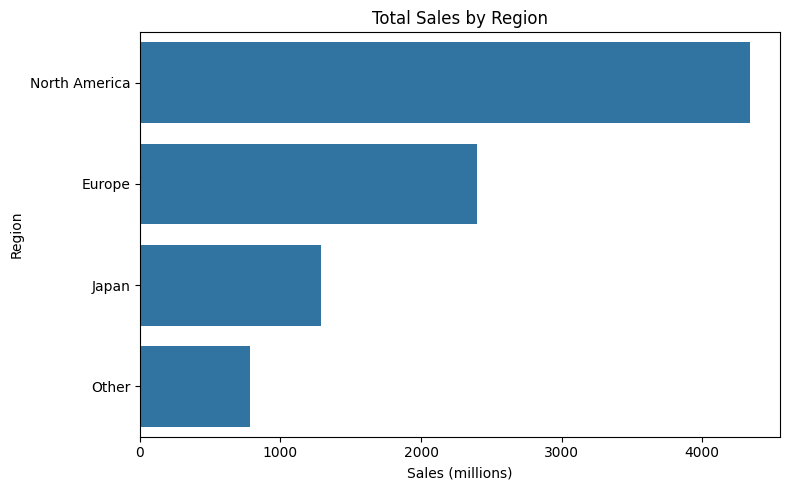

In [32]:
plt.figure(figsize=(8, 5))                                                                             
region_total = games_df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()      
sns.barplot(x=region_total.values, y=['North America', 'Europe', 'Japan', 'Other'], errorbar=None) 
plt.title('Total Sales by Region')                                                                     
plt.xlabel('Sales (millions)')                                                                         
plt.ylabel('Region')                                                                                   
plt.tight_layout()                                                                                     
plt.show()

> North America stands out as the largest market in this chart. Even so, the total values alone do not show the full picture, which is why the line chart below helps reveal a more detailed trend.

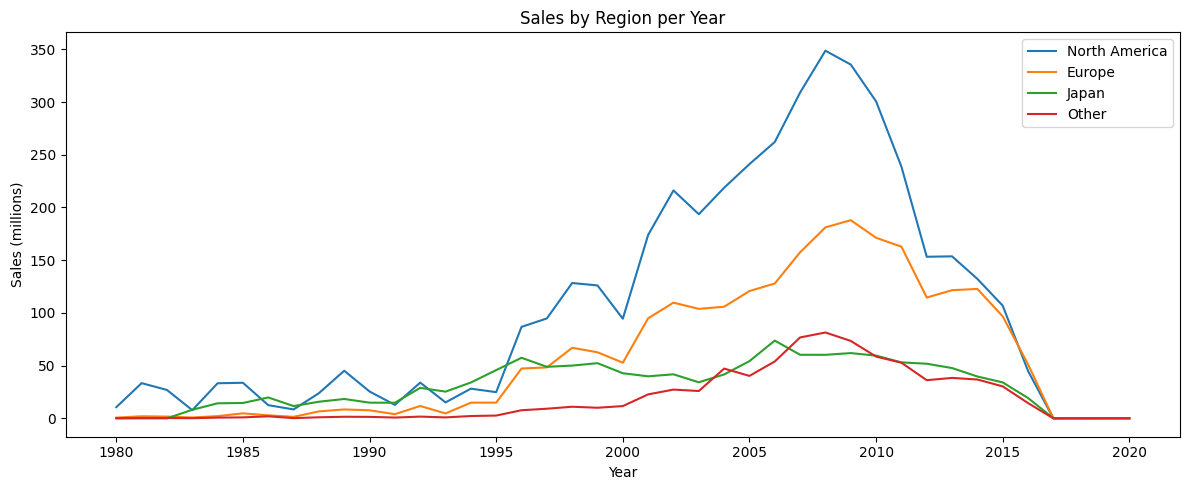

In [33]:
# Plot the trend between the different regions
region_year = games_df.groupby('Year_of_Release')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum() 
region_year.plot(kind='line', figsize=(12, 5))                                                     
plt.title('Sales by Region per Year')                                                              
plt.xlabel('Year')                                                                                 
plt.ylabel('Sales (millions)')                                                                     
plt.legend(['North America', 'Europe', 'Japan', 'Other'])                                          
plt.tight_layout()                                                                                
plt.show()

#### Regional Sales Conclusion

- In general, all markets follow a similar trend. North America is the largest market, but when sales decline, the drop is usually sharper than in the others.

- The European market most closely follows North America, although at a much smaller scale.

- The Japanese market is less profitable than the others, but it appears to be the most stable and consistent over time.

- The Other market also declined after 2009, but its relative share has grown, which may suggest increasing importance for developers.

- Overall, the data shows a clear decline across all markets since 2009, with no strong signs of recovery in the years shown.

## Feature Selection

The following features were selected based on the four analytical questions defined for this project. All remaining columns were excluded as they are not required to answer any of the questions.

| Question | Features Used |
|---|---|
| Top 5 games by global sales | `Name`, `Global_Sales` |
| Distribution of top 4 genres | `Genre` |
| Older vs newer games — median EU sales | `Year_of_Release`, `EU_Sales` |
| Most common developers | `Developer_Group` |

# QUESTIONS

## Question 1 - What are the top 5 games by global sales?  

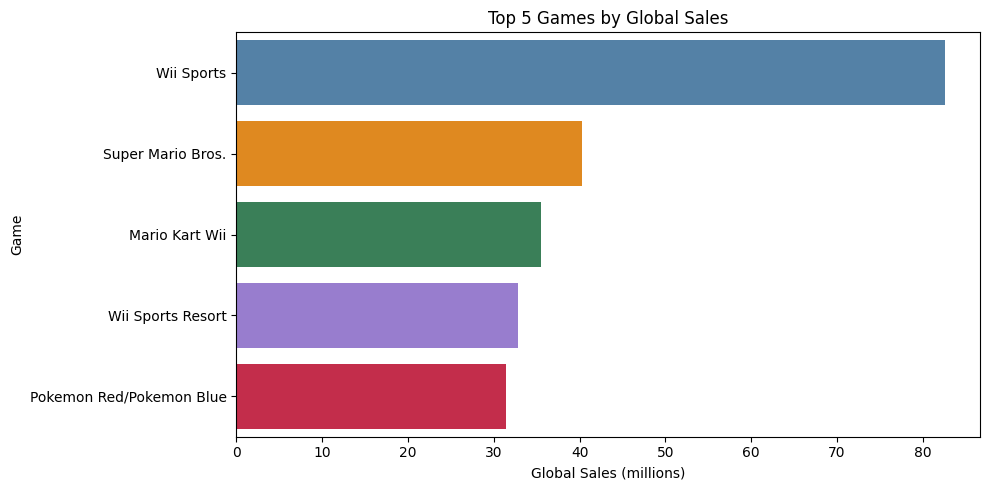

In [34]:
q1_df = games_df[['Name', 'Global_Sales']].copy()
top5 = q1_df.nlargest(5, 'Global_Sales')

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=top5['Global_Sales'], y=top5['Name'], errorbar=None,
                 palette=['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'crimson'])
plt.title('Top 5 Games by Global Sales')
plt.xlabel('Global Sales (millions)')
plt.ylabel('Game')
plt.tight_layout()
plt.show()

### Conclusion
Wii Sports leads global sales with 82.5 million units, far ahead of the other titles in the dataset. The remaining four games have much lower and relatively similar sales figures.

## Question 2 - What is the distribution of the most popular 4 game genres?

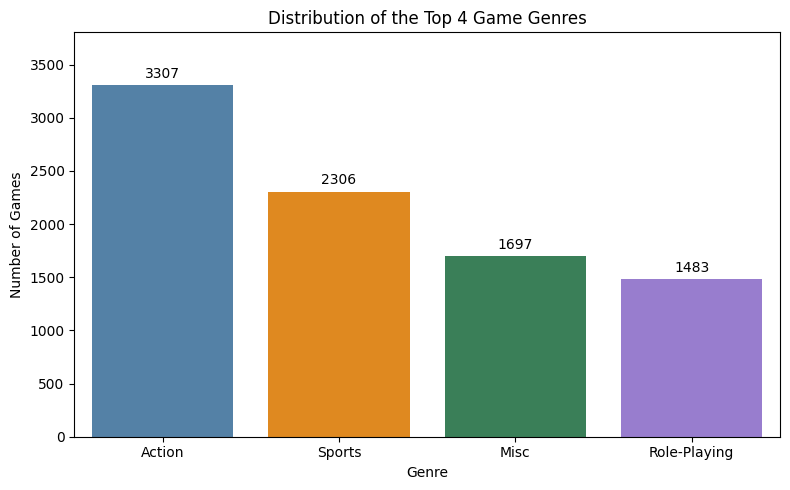

In [35]:
q2_df = games_df['Genre'].value_counts().head(4).reset_index()
q2_df.columns = ['Genre', 'Count']

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=q2_df, x='Genre', y='Count', errorbar=None,
                 palette=['steelblue', 'darkorange', 'seagreen', 'mediumpurple'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Distribution of the Top 4 Game Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.ylim(0, q2_df['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

### Conclusion
Action is the most frequent genre among the top four, followed by Sports, Shooter, and Role-Playing. Action appears significantly more common than Role-Playing, indicating a strong concentration in a few dominant genres.

## Question 3 - Do older games (2006 and earlier) have a higher MEDIAN “eu_sales” than newer games (after 2006)?  

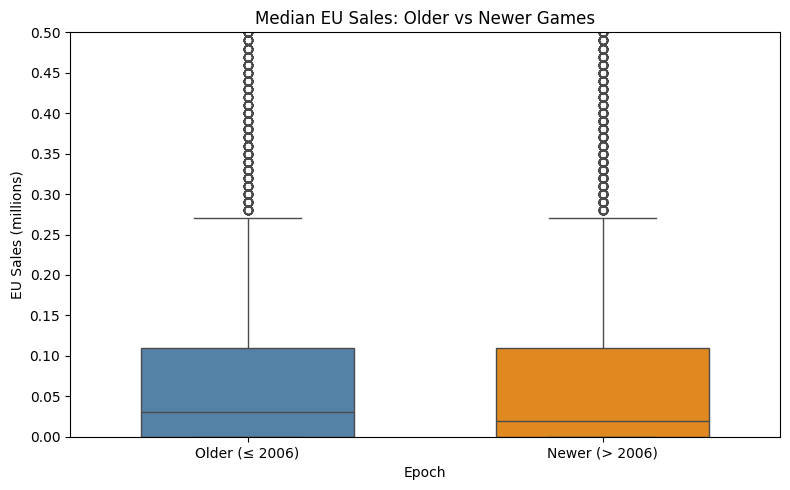

In [36]:
q3_df = games_df[['Year_of_Release', 'EU_Sales']].copy()
q3_df['Epoch'] = q3_df['Year_of_Release'].apply(lambda x: 'Older (≤ 2006)' if x <= 2006 else 'Newer (> 2006)')

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=q3_df, x='Epoch', y='EU_Sales', width=0.6, palette=['steelblue', 'darkorange'])
plt.title('Median EU Sales: Older vs Newer Games')
plt.xlabel('Epoch')
plt.ylabel('EU Sales (millions)')
plt.ylim(0, 0.5)                                                             # Define the outlier values in the graph
plt.yticks([0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5])
plt.tight_layout()
plt.show()

### Conclusion
- Older games (≤ 2006) have a lower median EU Sales than newer games (> 2006). Newer games also show greater variation in sales, as seen in the wider whiskers.
- Outliers were kept because they represent real extreme cases in the dataset. In this context, they are important since they show major commercial successes in the video game industry, which are part of the phenomenon being analyzed.

## QUESTION 4 - What are the 3 most common “developer” in the dataset?  

In [37]:
# View the most common developers before filtering Unknown
games_df['Developer_Group'].value_counts()

Developer_Group
Unknown                                      6512
Electronic Arts                               716
Ubisoft                                       451
Konami                                        171
Capcom                                        146
                                             ... 
High Moon Studios, Mercenary Technologies       1
Infinite Dreams, Paragon 5                      1
Big Red Software                                1
Atomic Games                                    1
Interchannel-Holon                              1
Name: count, Length: 1562, dtype: int64

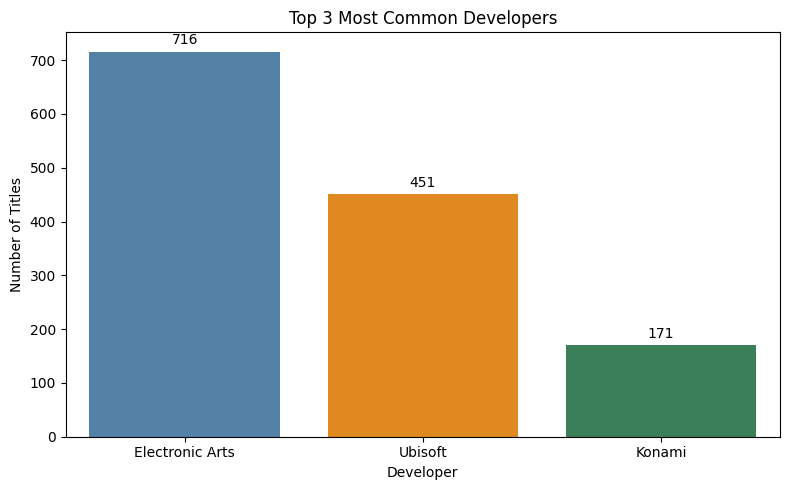

In [38]:
q4_df = games_df[games_df['Developer_Group'] != 'Unknown']['Developer_Group'].value_counts().head(3).reset_index()
q4_df.columns = ['Developer', 'Count']

plt.figure(figsize=(8, 5))
sns.barplot(data=q4_df, x='Developer', y='Count', errorbar=None,
           palette=['steelblue', 'darkorange', 'seagreen'])
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)
plt.title('Top 3 Most Common Developers')
plt.xlabel('Developer')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

### Conclusion
- Electronic Arts is the most frequent developer among the top 3, with 716 titles. Ubisoft ranks second with 451 titles, while Konami appears third with 171. This indicates a strong concentration in the top positions, with Electronic Arts clearly dominating this group.

## Analysis Conclusion

- Overall, the data suggest that the video game market is highly concentrated, both in terms of developers and sales, with a small number of titles and companies dominating the results.

- It also became clear that sales vary substantially across regions and that, although many games are classified as "Action," this category is broad and should be interpreted with caution.

- Taken together, the results suggest that commercial success depends not only on the number of games released, but also on individual titles with strong market impact.

# References
- contributors, M.C. (n.d.). Basic Syntax | Markdown Guide. [online] www.markdownguide.org. Available at: https://www.markdownguide.org/basic-syntax/. (Accessed: 10 May 2026)
- McQuaid, D. (2026) What Visualization Should I Use v3 [PowerPoint slides]. Data Visualisation and Communication. CCT College Dublin. Unpublished. (Accessed: 10 May 2026)
- jxn (2018). x axis gets transformed to floats. [online] Stack Overflow. Available at: https://stackoverflow.com/questions/48715330/x-axis-gets-transformed-to-floats.‌(Accessed: 4 June 2026)
- Matplotlib (2012). List of Named Colors — Matplotlib 3.4.2 Documentation. [online] matplotlib.org. Available at: https://matplotlib.org/stable/gallery/color/named_colors.html. (Accessed: 5 June 2026)